### PLOTS FOR PAPER RESULTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/var/folders/hh/2dsrbb3d021_w0zs6jdygn480000gn/T/ipykernel_63530/1165525899.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beta_results['Parameter'] = beta_results['Parameter'].str.replace('beta\\[', 'beta_', regex=True).str.replace('\\]', '', regex=True)


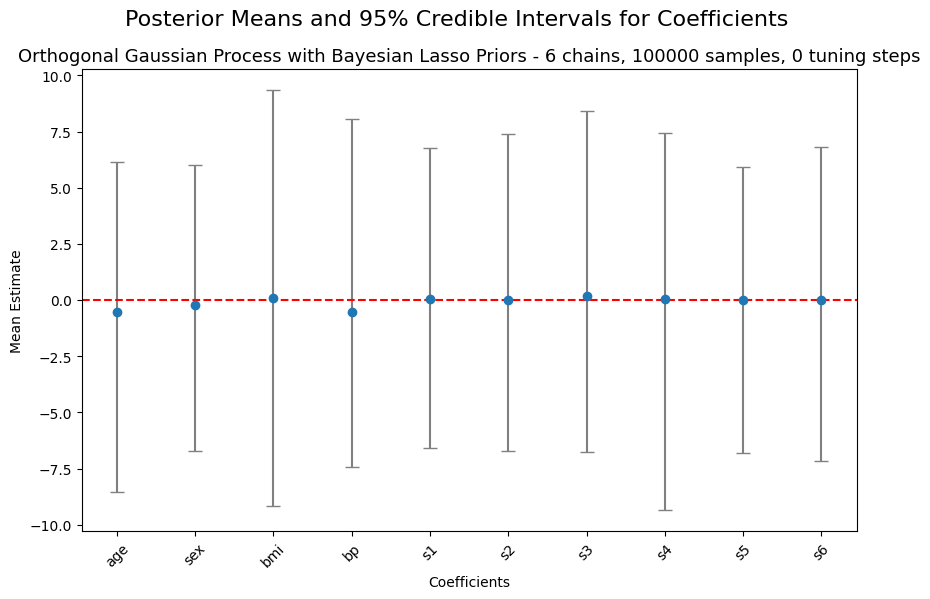

In [80]:
##  plot coefficients and confidence intervals from 

###################

path = 'results/BL_GP/11-06_diabetes/Metropolis/dr10000_t0_ch6/sd1/posterior_summary.csv'

model_name = 'Orthogonal Gaussian Process with Bayesian Lasso Priors'
model_desc = '6 chains, 100000 samples, 0 tuning steps'

####################

post_sum = pd.read_csv(path)

# extract coefficient rows and confidence intervals
post_sum = post_sum.rename(columns={'Unnamed: 0': 'Parameter'})

# filter for coefficients 
beta_results = post_sum[post_sum['Parameter'].str.contains('beta')]

# rename to beta_0 instead of beta[0]
beta_results['Parameter'] = beta_results['Parameter'].str.replace('beta\\[', 'beta_', regex=True).str.replace('\\]', '', regex=True)

# map real names to beta_0, beta_1, etc.
features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

for i, feature in enumerate(features):
    beta_results.loc[beta_results['Parameter'] == f'beta_{i}', 'Parameter'] = feature

# plot
plt.figure(figsize=(10, 6))
plt.errorbar(beta_results['Parameter'], beta_results['mean'], 
             yerr=[beta_results['mean'] - beta_results['hdi_2.5%'], 
                   beta_results['hdi_97.5%'] - beta_results['mean']], 
             fmt='o', ecolor='gray', capsize=5)
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.xlabel('Coefficients')
plt.ylabel('Mean Estimate')

# add subtitle with model details
plt.suptitle('Posterior Means and 95% Credible Intervals for Coefficients', fontsize=16)
plt.title(model_name + ' - ' + model_desc, fontsize=13)
plt.show()
